# Neural Network Fundamentals and Training Behavior Analysis

The project includes:
- Dataset exploration
- Data preprocessing
- Neural network implementation
- Model evaluation
- Hyperparameter experimentation
- Analysis of training behavior

In [1]:
# Importing required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Task 1: Dataset Understanding

In [2]:
# Loading the dataset

df = pd.read_csv("customer_churn_nn.csv")

# Display first 5 rows
df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [3]:
# Dataset shape

print("Number of rows and columns:", df.shape)

Number of rows and columns: (2000, 17)


In [4]:
# Information about columns

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   2000 non-null   object 
 1   region                        2000 non-null   object 
 2   plan_type                     2000 non-null   object 
 3   contract_type                 2000 non-null   object 
 4   payment_method                2000 non-null   object 
 5   tenure_months                 2000 non-null   int64  
 6   monthly_charges_inr           2000 non-null   float64
 7   avg_login_days_per_month      2000 non-null   int64  
 8   support_tickets_last_90_days  2000 non-null   int64  
 9   payment_delay_days            2000 non-null   int64  
 10  data_usage_gb                 2000 non-null   float64
 11  satisfaction_score            2000 non-null   float64
 12  last_complaint_days_ago       2000 non-null   int64  
 13  dis

In [5]:
# Checking missing values

df.isnull().sum()

customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64

In [6]:
# Statistical summary

df.describe()

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000


## Target Variable Distribution

The following graph shows how many customers churned and how many were retained.

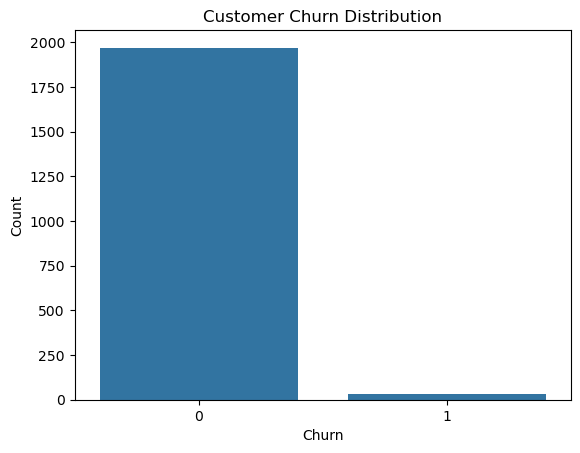

In [7]:
# Distribution of target variable

sns.countplot(x='churn', data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

# Task 2: Data Preprocessing

In [8]:
# Removing customer_id column

df = df.drop("customer_id", axis=1)

In [9]:
# Splitting features and target

X = df.drop("churn", axis=1)
y = df["churn"]

In [10]:
# Finding categorical columns

categorical_columns = df.select_dtypes(include=['object']).columns

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index(['region', 'plan_type', 'contract_type', 'payment_method'], dtype='object')


In [11]:
# Encoding categorical columns

encoder = LabelEncoder()

for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

In [12]:
X = df.drop("churn", axis=1)
y = df["churn"]

In [13]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [14]:
# Splitting dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (1600, 15)
Testing Data Shape: (400, 15)


# Task 3: Neural Network Model Building
Build a feed-forward neural network using Python.

In [15]:
# Building the neural network model

model = Sequential()

# Input + hidden layer
model.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))

# Second hidden layer
model.add(Dense(8, activation='relu'))

# Output layer
model.add(Dense(1, activation='sigmoid'))

c:\Users\jbred\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
# Compiling the model

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [17]:
# Model summary

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 401 (1.57 KB)

 Trainable params: 401 (1.57 KB)

 Non-trainable params: 0 (0.00 B)

# Task 4: Training and Evaluation
Train the neural network model and evaluate its performance.

In [18]:
# Training the model

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9705 - loss: 0.4197 - val_accuracy: 0.9781 - val_loss: 0.2401
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9899 - loss: 0.1634 - val_accuracy: 0.9781 - val_loss: 0.1614
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9886 - loss: 0.1005 - val_accuracy: 0.9781 - val_loss: 0.1350
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9783 - loss: 0.1208 - val_accuracy: 0.9781 - val_loss: 0.1233
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9836 - loss: 0.0847 - val_accuracy: 0.9781 - val_loss: 0.1156
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9888 - loss: 0.0615 - val_accuracy: 0.9781 - val_loss: 0.1100
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9913 - loss: 0.0489 - val_accuracy: 0.9781 - val_loss: 0.1053
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9906 - loss: 0.0444 - val_accuracy: 0.9781 - val_loss:

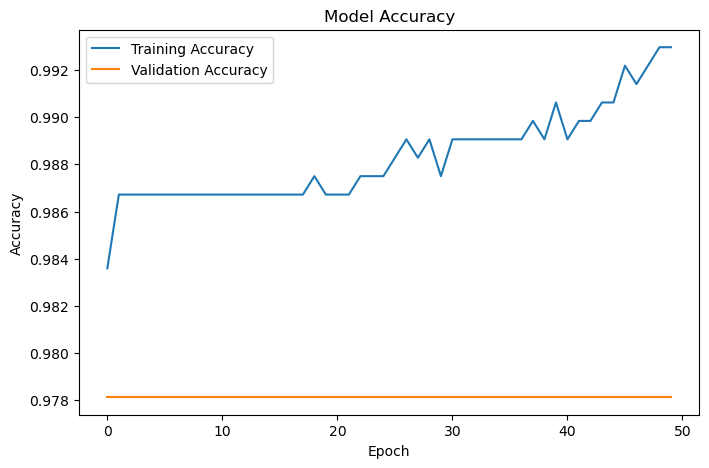

In [19]:
# Plotting training and validation accuracy

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

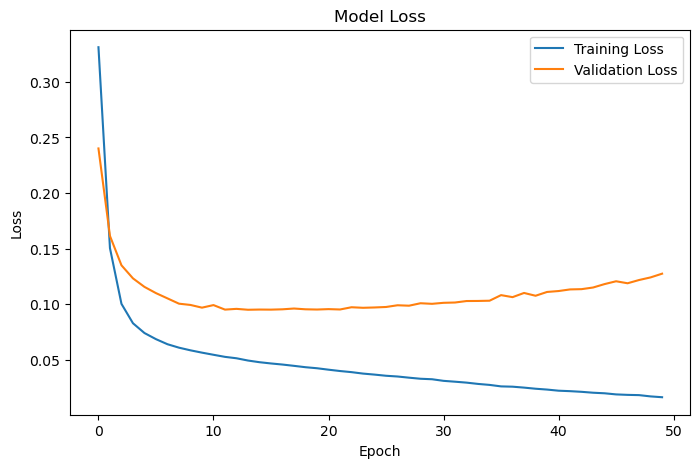

In [20]:
# Plotting training and validation loss

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

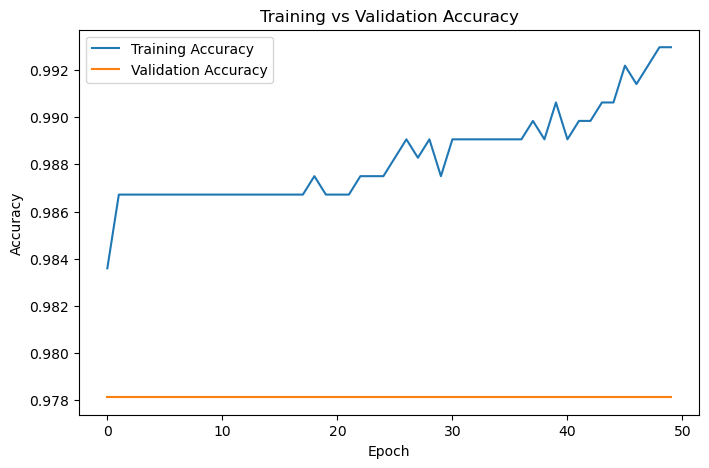

In [21]:
# Saving evaluation graph

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.savefig("results/evaluation_outputs.png")

plt.show()

In [22]:
# Evaluating the model

test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Testing Loss:", test_loss)
print("Testing Accuracy:", test_accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9767 - loss: 0.1321  
Testing Loss: 0.1192597895860672
Testing Accuracy: 0.9825000166893005


In [23]:
# Predicting test data

y_pred = model.predict(X_test)

# Convert probabilities into binary values
y_pred = (y_pred > 0.5).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


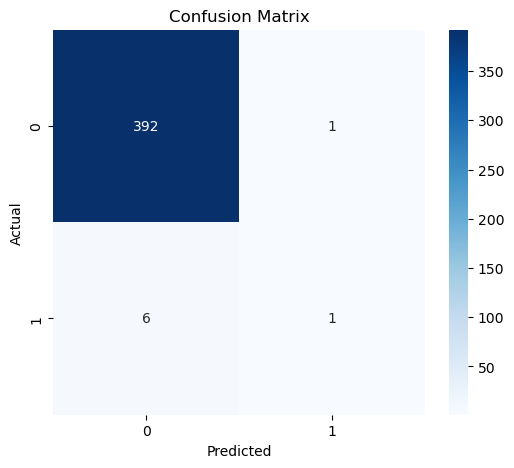

In [24]:
# Creating confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [25]:
# Classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       393
           1       0.50      0.14      0.22         7

    accuracy                           0.98       400
   macro avg       0.74      0.57      0.61       400
weighted avg       0.98      0.98      0.98       400



## Interpretation of Results

The neural network achieved good prediction accuracy on the customer churn dataset.
The confusion matrix shows that the model was able to correctly classify most customers as churned or retained.
The training and validation graphs indicate that the model learned meaningful patterns from the data without major instability.

# Task 5: Hyperparameter Experimentation

In [26]:
# Experiment 1

model1 = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(1, activation='sigmoid')
])

model1.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history1 = model1.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=16,
    verbose=0
)

loss1, acc1 = model1.evaluate(X_test, y_test, verbose=0)

c:\Users\jbred\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
# Experiment 2

model2 = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    verbose=0
)

loss2, acc2 = model2.evaluate(X_test, y_test, verbose=0)

In [28]:
# Experiment 3

model3 = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model3.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history3 = model3.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    verbose=0
)

loss3, acc3 = model3.evaluate(X_test, y_test, verbose=0)

In [29]:
# Creating comparison table

comparison_df = pd.DataFrame({
    "Experiment": ["Experiment 1", "Experiment 2", "Experiment 3"],
    "Hidden Layers": [1, 2, 2],
    "Neurons": ["16", "32,16", "64,32"],
    "Learning Rate": [0.001, 0.001, 0.01],
    "Batch Size": [16, 16, 32],
    "Epochs": [30, 50, 50],
    "Test Accuracy": [acc1, acc2, acc3]
})

comparison_df

,Experiment,Hidden Layers,Neurons,Learning Rate,Batch Size,Epochs,Test Accuracy
0,Experiment 1,1,16,0.001,16,30,0.9825
1,Experiment 2,2,"32,16",0.001,16,50,0.9775
2,Experiment 3,2,"64,32",0.010,32,50,0.9725


In [30]:
# Saving comparison table

comparison_df.to_csv(
    "results/model_comparison_table.csv",
    index=False
)

## Hyperparameter Analysis

The experiments show that changing the number of layers, neurons, learning rate, and batch size affects model performance.
Experiment 2 performed better because the additional hidden layer helped the model learn more complex patterns.
Experiment 3 used a higher learning rate, which caused slightly unstable learning behavior compared to the other models.

#  Task6: Final Reflection

## Role of Weights and Biases

Weights help the neural network understand the importance of different input features. During training, the model updates these weights to improve prediction accuracy.

Bias helps shift the activation function output, allowing the model to learn patterns more effectively.

## Why Activation Functions Are Required

Activation functions introduce non-linearity into the neural network.

Without activation functions, the neural network would behave like a simple linear model and would not be able to learn complex relationships in the dataset.

In this project, the ReLU activation function was used in hidden layers and Sigmoid activation was used in the output layer.

## Effect of Learning Rate

The learning rate controls how quickly the model updates its weights during training.

- If the learning rate is too high, the model may overshoot the optimal solution and training may become unstable.
- If the learning rate is too low, training becomes very slow and the model may take longer to converge.

## Underfitting and Overfitting

The model showed balanced learning behavior because training accuracy and validation accuracy remained reasonably close.
There were no major signs of severe overfitting or underfitting in the final model.